In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

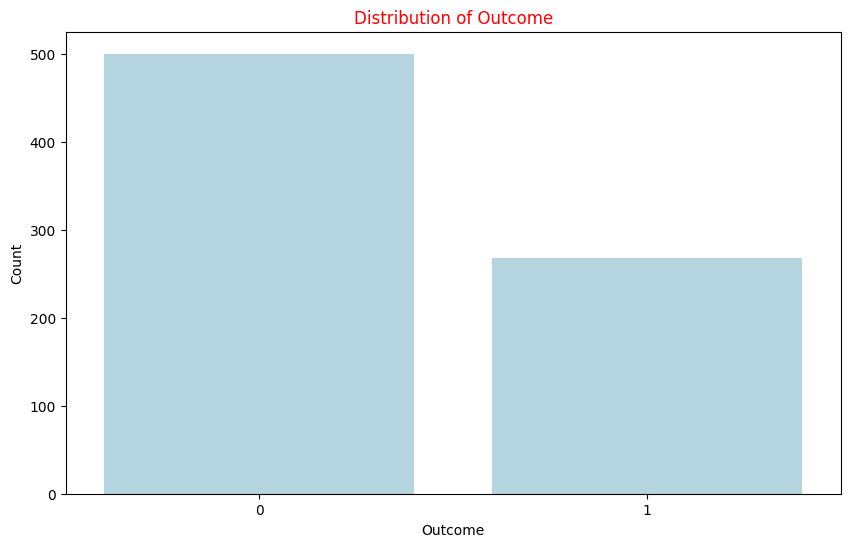

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Outcome', data=df, color='lightblue')
plt.title('Distribution of Outcome',color='red')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

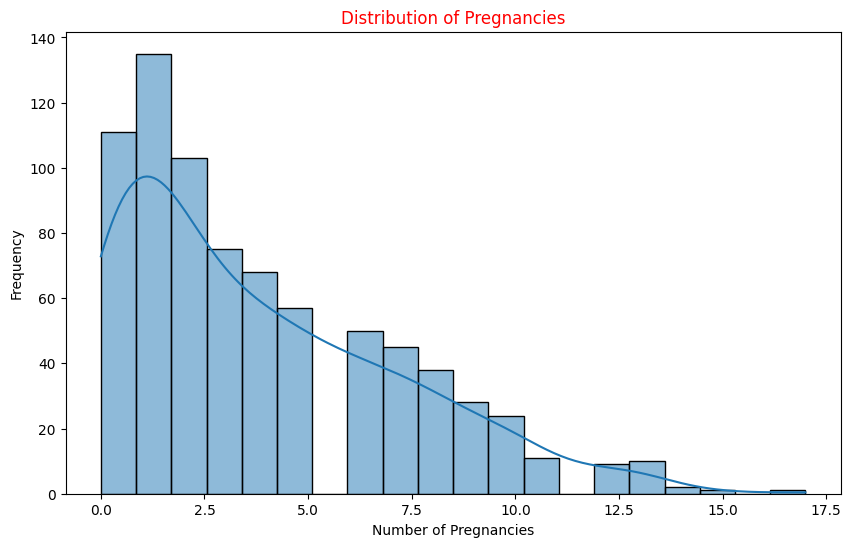

In [9]:
# Distribution of Pregnancies
plt.figure(figsize=(10, 6))
sns.histplot(df['Pregnancies'], bins=20, kde=True)
plt.title('Distribution of Pregnancies',color='red')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Frequency')
plt.show()


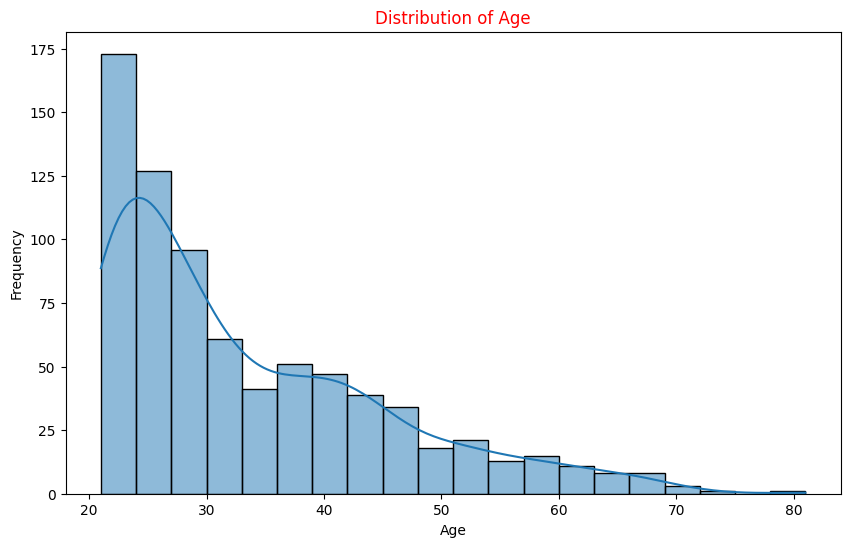

In [10]:
# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age',color='red')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


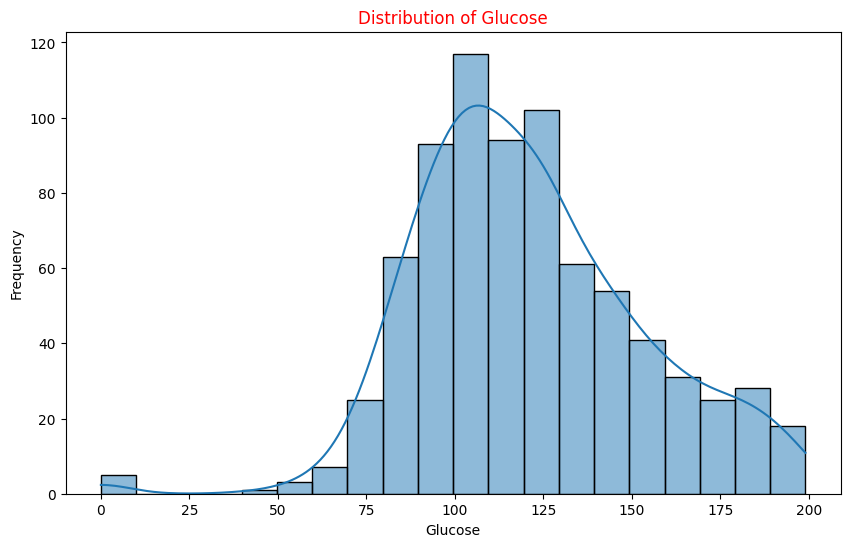

In [11]:
# Distribution of Glucose
plt.figure(figsize=(10, 6))
sns.histplot(df['Glucose'], bins=20, kde=True)
plt.title('Distribution of Glucose',color='red')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()


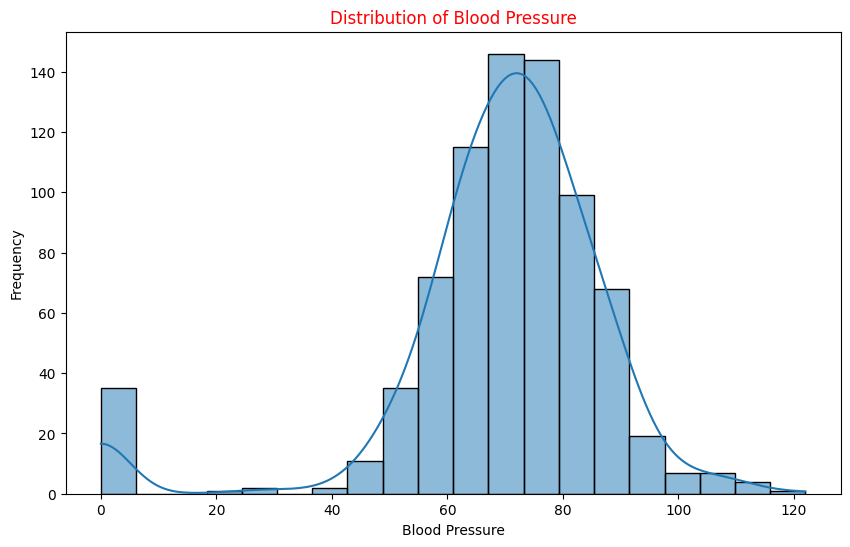

In [12]:
# Distribution of Blood Pressure
plt.figure(figsize=(10, 6))
sns.histplot(df['BloodPressure'], bins=20, kde=True)
plt.title('Distribution of Blood Pressure',color='red')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.show()


## Dataset Split

In [13]:
X = df.drop(columns='Outcome', axis=1)
y = df['Outcome']

X.shape, y.shape

((768, 8), (768,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((614, 8), (154, 8))

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Building

In [16]:
svc = SVC(kernel='linear')

svc.fit(X_train, y_train)

SVC(kernel='linear')

In [17]:
y_pred = svc.predict(X_test)    

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.760

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [18]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lr):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy Score: 0.753

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy Score: 0.721

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



## Prediction

In [20]:
input_data = (5,166,72,19,175,25.8,0.587,51)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

std_data = scaler.transform(input_data_reshaped)

prediction = svc.predict(std_data)
print("Prediction :",prediction)

if (prediction[0] == 0):
  print('The person is not Diabetic')
else:
  print('The person is Diabetic')

Prediction : [1]
The person is Diabetic


## Saving the Model

In [21]:
import pickle

In [22]:
pickle.dump(svc, open('svc_model.pkl', 'wb'))

In [23]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))